## Xenium data


## Notebook roadmap
1. Load libraries and paths.
2. Load 5K and V1 SpatialData objects.
3. Compare core QC distributions with overlaid histograms.
4. Build overlap-gene subset shared by both panels.
5. Compute detection and expression statistics on overlap genes.
6. Run optional downstream analyses (UMAP/Leiden + spatial plots).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import scipy.sparse as sp
import spatialdata as sd
import squidpy as sq
from scipy.sparse import issparse
import zarr
import anndata as ad
import annsel as an 
from scipy.sparse import csr_matrix
from scipy.stats import linregress, pearsonr, spearmanr
import spatialdata
import spatialdata_io
import spatialdata as sd
from spatialdata.models import PointsModel
from spatialdata.transformations import get_transformation, set_transformation
from spatialdata_io import xenium
from spatialdata import bounding_box_query
import spatialdata_plot


# Base directories for the folders containing the data for the two versions of the Xenium platform
BASE_5K = Path("C://Users//ntpar//Downloads//Xenium_Prime_Human_Lung_Cancer_FFPE_xe_outs")
BASE_V1 = Path("C://Users//ntpar//Downloads//Xenium_V1_Human_Lung_Cancer_FFPE_xe_outs")


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
c:\Users\ntpar\AppData\Local\Programs\Python\Pytho

## 1) SpatialData loading

In [2]:
sdata_5k = spatialdata_io.xenium(BASE_5K)
adata_5k = sdata_5k.tables["table"]
sdata_5k

C:\Users\ntpar\AppData\Local\Temp\ipykernel_10148\92766341.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_5k = spatialdata_io.xenium(BASE_5K)
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 37348, 54086), (4, 18674, 27043), (4, 9337, 13521), (4, 4668, 6760), (4, 2334, 3380)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
│     └── 'nucleus_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (278328, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (275207, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (278328, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (S

In [3]:
sdata_v1 = spatialdata_io.xenium(BASE_V1)
adata_v1 = sdata_v1.tables["table"]
sdata_v1

C:\Users\ntpar\AppData\Local\Temp\ipykernel_10148\4111237452.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_v1 = spatialdata_io.xenium(BASE_V1)
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 34191, 54061), (1, 17095, 27030), (1, 8547, 13515), (1, 4273, 6757), (1, 2136, 3378)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34191, 54061), (17095, 27030), (8547, 13515), (4273, 6757), (2136, 3378)
│     └── 'nucleus_labels': DataTree[yx] (34191, 54061), (17095, 27030), (8547, 13515), (4273, 6757), (2136, 3378)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278659, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (278659, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (278659, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (278659, 289)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Sh

In [4]:
#Stable raw references so re-running filtering cells is threshold-dependent
sdata_5k_raw = sdata_5k
sdata_v1_raw = sdata_v1
adata_5k_raw = sdata_5k_raw.tables["table"]
adata_v1_raw = sdata_v1_raw.tables["table"]


## testing stuff (like plotting images)

The function for the HE image doesnt work, since it's not in the file yet

In [ ]:
#  TABLE (AnnData) 
# sdata_5k.pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image")
sdata_5k.pl.render_images("morphology_focus").pl.show(title="Morphology image")

We normalize the count

In [6]:
# sc.pp.normalize_total(sdata_5k.tables["table"])
# sc.pp.log1p(sdata_5k.tables["table"])
# sc.pp.highly_variable_genes(sdata_5k.tables["table"])
# sdata_5k.tables["table"].var.sort_values("means")

# sc.pp.normalize_total(sdata_v1.tables["table"])
# sc.pp.log1p(sdata_v1.tables["table"])
# sc.pp.highly_variable_genes(sdata_v1.tables["table"])
# sdata_v1.tables["table"].var.sort_values("means")

C:\Users\ntpar\AppData\Local\Temp\ipykernel_23708\1714989975.py:1: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(sdata_5k.tables["table"])
C:\Users\ntpar\AppData\Local\Temp\ipykernel_23708\1714989975.py:6: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(sdata_v1.tables["table"])


,gene_ids,feature_types,genome,highly_variable,means,dispersions,dispersions_norm
TCL1A,ENSG00000100721,Gene Expression,,False,0.000337,0.536875,-0.874423
WT1,ENSG00000184937,Gene Expression,,False,0.002491,0.787087,-0.349143
CD70,ENSG00000125726,Gene Expression,,False,0.002794,0.449053,-1.058792
SMIM24,ENSG00000095932,Gene Expression,,False,0.002870,0.510241,-0.930337
FOXI1,ENSG00000168269,Gene Expression,,False,0.003209,1.591095,1.338746
...,...,...,...,...,...,...,...
MUC1,ENSG00000185499,Gene Expression,,True,0.700890,1.321355,0.707107
EPCAM,ENSG00000119888,Gene Expression,,False,0.733956,1.300600,-0.707107
CDH1,ENSG00000039068,Gene Expression,,True,0.741527,1.437654,1.000000
LTBP2,ENSG00000119681,Gene Expression,,True,0.817253,1.860388,1.000000


In [147]:
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[20_000, 8000],
        max_coordinate=[22_000, 8500],
        axes=("x", "y"),
        target_coordinate_system="global",
    )


In [ ]:
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[20_000, 8000],
        max_coordinate=[22_000, 8500],
        axes=("x", "y"),
        target_coordinate_system="global",
    )


gene_name = "EPCAM"
crop0(sdata_5k).pl.render_images("morphology_focus", channel="DAPI", cmap="gray").pl.render_shapes(
    "cell_circles",
    color=gene_name,
).pl.show(
    title=f"{gene_name} expression over Morphology image",
    coordinate_systems="global",
    figsize=(10, 3),
)

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


## QC: Filtering cells & transcripts

### Calculating extra rows 

sc.pp.calculate_qc_metrics calculates these variables: 
- 'n_genes_by_counts',
- 'log1p_n_genes_by_counts', 
- 'total_counts', 
- 'log1p_total_counts', 
- 'pct_counts_in_top_50_genes', 
- 'pct_counts_in_top_100_genes', 
- 'pct_counts_in_top_200_genes', 
- 'pct_counts_in_top_289_genes'

In [5]:
adata_5k = sdata_5k.tables["table"]
sc.pp.calculate_qc_metrics(adata_5k, inplace=True)
adata_5k 

adata_v1 = sdata_v1.tables["table"]
pt = tuple((50, 100, 200, 289))
sc.pp.calculate_qc_metrics(adata_v1, inplace=True, percent_top = pt)
adata_v1

AnnData object with n_obs × n_vars = 278659 × 289
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_289_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [6]:
adata_5k.var

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A2ML1,ENSG00000166535,Gene Expression,,139,0.000507,0.000506,99.950059,141.0,4.955827
AAMP,ENSG00000127837,Gene Expression,,30965,0.137331,0.128684,88.874637,38223.0,10.551219
AAR2,ENSG00000131043,Gene Expression,,10062,0.040614,0.039811,96.384841,11304.0,9.333000
AARSD1,ENSG00000266967,Gene Expression,,15756,0.068276,0.066046,94.339053,19003.0,9.852405
ABAT,ENSG00000183044,Gene Expression,,12718,0.059509,0.057806,95.430571,16563.0,9.714987
...,...,...,...,...,...,...,...,...,...
ZSCAN26,ENSG00000197062,Gene Expression,,9236,0.035918,0.035288,96.681613,9997.0,9.210140
ZSWIM6,ENSG00000130449,Gene Expression,,7652,0.029063,0.028649,97.250726,8089.0,8.998384
ZUP1,ENSG00000153975,Gene Expression,,6539,0.024773,0.024471,97.650614,6895.0,8.838696
ZYG11B,ENSG00000162378,Gene Expression,,11645,0.045860,0.044839,95.816087,12764.0,9.454462


In [7]:
adata_5k.obs 

,cell_id,cell_area,nucleus_centroid_x,nucleus_centroid_y,nucleus_area,z_level,nucleus_count,region,cell_labels,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
0,aaaaadnb-1,44.659533,822.510193,5111.534668,21.223438,0.0,1.0,cell_circles,1,187,5.236442,226.0,5.424950,39.380531,61.504425,100.000000,100.0
1,aaaabalp-1,32.196407,842.814270,5149.195801,9.889219,0.0,1.0,cell_circles,2,101,4.624973,108.0,4.691348,52.777778,99.074074,100.000000,100.0
2,aaaadfei-1,47.504377,831.367126,5133.042969,25.739063,0.0,1.0,cell_circles,3,224,5.416100,265.0,5.583496,34.339623,53.207547,90.943396,100.0
3,aaaadjia-1,37.253908,840.766052,5159.806641,20.636407,0.0,1.0,cell_circles,4,256,5.549076,328.0,5.796058,37.195122,52.439024,82.926829,100.0
4,aaaafglb-1,52.155471,784.202820,5143.686523,27.274376,0.0,1.0,cell_circles,5,261,5.568345,337.0,5.823046,37.388724,52.225519,81.899110,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278323,oikioede-1,41.001876,7466.501465,945.195374,41.001876,7.0,1.0,cell_circles,278324,63,4.158883,76.0,4.343805,82.894737,100.000000,100.000000,100.0
278324,oikiokmm-1,26.416407,7359.069336,1029.273926,26.416407,6.0,1.0,cell_circles,278325,12,2.564949,12.0,2.564949,100.000000,100.000000,100.000000,100.0
278325,oikjekcf-1,37.976408,7380.614746,856.629333,27.545313,6.0,1.0,cell_circles,278326,62,4.143135,73.0,4.304065,83.561644,100.000000,100.000000,100.0
278326,oikjghfi-1,26.326095,7347.087402,859.275513,7.857188,5.0,1.0,cell_circles,278327,9,2.302585,9.0,2.302585,100.000000,100.000000,100.000000,100.0


### Cell filtering
- We filter the cells with less than 10 transcripts
- We also filter the transcripts with a QV < 20 out
    - What's nice is that these transcripts are automatically already not included in the table for the cells, so we don't have to change anything about total_counts etc.
    - The qv column in Xenium’s transcript table is a Phred-scaled “Q-Score” that represents confidence in each decoded transcript call. Conceptually, it’s a rescaling of an estimated error probability: higher qv means lower probability that the transcript identity/call is incorrect

In [ ]:
import spatialdata as sd
from spatialdata.models import PointsModel
from spatialdata.transformations import get_transformation, set_transformation
import dask.dataframe as dd

def fast_filter_table_and_transcripts(sdata, adata_f, transcripts_key="transcripts"):
    # We copy the points & shapes dicts so we don't modify the data in-place
    points = dict(sdata.points)
    shapes = dict(sdata.shapes)

    tx = points[transcripts_key]
    use_cell_merge = False

    # We filter out the transcripts by merging with the filtered cells in the filtered adata_f
    if "cell_id" in tx.columns and "cell_id" in adata_f.obs.columns:
        tx_cell = tx["cell_id"].astype(str)
        if isinstance(tx_cell, dd.Series):
            n_non_empty = int((tx_cell.str.len() > 0).sum().compute())
        else:
            n_non_empty = int((tx_cell.str.len() > 0).sum())
        use_cell_merge = n_non_empty > 0

    if use_cell_merge:
        kept_cells = adata_f.obs[["cell_id"]].copy()
        kept_cells["cell_id"] = kept_cells["cell_id"].astype(str)
        kept_cells_dd = dd.from_pandas(kept_cells, npartitions=1)
        tx = tx.assign(cell_id=tx["cell_id"].astype(str))
        tx_f = tx.merge(kept_cells_dd, on="cell_id", how="inner")
    else:
        print("Warning: transcript cell_id values are empty/unusable; skipping transcript-to-cell merge.")
        tx_f = tx

    tx_f = PointsModel.parse(tx_f)
    t = get_transformation(points[transcripts_key], to_coordinate_system="global")
    set_transformation(tx_f, t, to_coordinate_system="global")
    points[transcripts_key] = tx_f

    if "cell_circles" in shapes and getattr(shapes["cell_circles"].index, "dtype", None) == object:
        kept_idx = set(adata_f.obs["cell_id"].astype(str)) if "cell_id" in adata_f.obs.columns else set()
        shapes["cell_circles"] = shapes["cell_circles"].loc[
            shapes["cell_circles"].index.intersection(kept_idx)
        ]

    return sd.SpatialData(
        images=dict(sdata.images),
        labels=dict(sdata.labels),
        points=points,
        shapes=shapes,
        tables={**dict(sdata.tables), "table": adata_f},
        attrs=sdata.attrs,
    )

In [9]:
threshold = 30
adata_5k_f = adata_5k_raw[adata_5k_raw.obs["total_counts"] >= threshold].copy()
sdata_5k_f = fast_filter_table_and_transcripts(sdata_5k_raw, adata_5k_f, transcripts_key="transcripts")

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


In [10]:
threshold = 30
adata_v1_f = adata_v1_raw[adata_v1_raw.obs["total_counts"] >= threshold].copy()
sdata_v1_f = fast_filter_table_and_transcripts(sdata_v1_raw, adata_v1_f, transcripts_key="transcripts")

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


In [11]:
adata_5k = sdata_5k_f.tables["table"]
adata_v1 = sdata_v1_f.tables["table"]

print(f"Original 5K data shape: {adata_5k_raw.obs.shape}")
print(f"Filtered 5K data shape: {adata_5k.obs.shape}")
print(f"There were {adata_5k_raw.obs.shape[0] - adata_5k.obs.shape[0]} cells filtered out from the 5K dataset.")

print(f"Original V1 data shape: {adata_v1_raw.obs.shape}")
print(f"Filtered V1 data shape: {adata_v1.obs.shape}")
print(f"There were {adata_v1_raw.obs.shape[0] - adata_v1.obs.shape[0]} cells filtered out from the V1 dataset.")

Original 5K data shape: (278328, 17)
Filtered 5K data shape: (267436, 17)
There were 10892 cells filtered out from the 5K dataset.
Original V1 data shape: (278659, 17)
Filtered V1 data shape: (217899, 17)
There were 60760 cells filtered out from the V1 dataset.


### (Optional?) Remove QV<20 transcripts
(Optional?): Are we using the transcripts?

In [12]:
tx_5k = sdata_5k_f.points["transcripts"]
tx_5k_f = tx_5k[tx_5k["qv"] >= 20]

tx_v1 = sdata_v1_f.points["transcripts"]
tx_v1_f = tx_v1[tx_v1["qv"] >= 20]

n_before_5k = tx_5k.shape[0].compute()
n_after_5k = tx_5k_f.shape[0].compute()
if n_before_5k > 0:
    print(f"5K: Removed {n_before_5k - n_after_5k:,} transcripts ({(n_before_5k - n_after_5k)/n_before_5k:.2%}).")
else:
    print("5K: No transcripts available before QV filtering.")

n_before_v1 = tx_v1.shape[0].compute()
n_after_v1 = tx_v1_f.shape[0].compute()
if n_before_v1 > 0:
    print(f"V1: Removed {n_before_v1 - n_after_v1:,} transcripts ({(n_before_v1 - n_after_v1)/n_before_v1:.2%}).")
else:
    print("V1: No transcripts available before QV filtering.")

# Persist filtered transcripts in the filtered SpatialData objects used downstream
tx_5k_f = PointsModel.parse(tx_5k_f)
t_5k = get_transformation(sdata_5k_f.points["transcripts"], to_coordinate_system="global")
set_transformation(tx_5k_f, t_5k, to_coordinate_system="global")
sdata_5k_f.points["transcripts"] = tx_5k_f

tx_v1_f = PointsModel.parse(tx_v1_f)
t_v1 = get_transformation(sdata_v1_f.points["transcripts"], to_coordinate_system="global")
set_transformation(tx_v1_f, t_v1, to_coordinate_system="global")
sdata_v1_f.points["transcripts"] = tx_v1_f

print("Persisted qv>=20 filtered transcripts into sdata_5k_f and sdata_v1_f.")

5K: Removed 27,768,458 transcripts (15.65%).
V1: Removed 1,183,011 transcripts (3.69%).


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


Persisted qv>=20 filtered transcripts into sdata_5k_f and sdata_v1_f.


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:975: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return dispatch(args[0].__class__).__get__(obj, cls)(*args, **kwargs)


### Using only overlapping genes 

In [13]:
# Promote filtered SpatialData objects, keep only overlapping genes, and refresh QC
sdata_5k = sdata_5k_f
sdata_v1 = sdata_v1_f

overlap_genes = sorted(set(adata_5k.var_names).intersection(set(adata_v1.var_names)))
print("Number of overlapping genes:", len(overlap_genes))

overlap_genes_idx = pd.Index(overlap_genes)
adata_5k = sdata_5k.tables["table"][:, overlap_genes_idx].copy()
adata_v1 = sdata_v1.tables["table"][:, overlap_genes_idx].copy()

assert adata_5k.var_names.equals(adata_v1.var_names)
assert set(adata_5k.var_names) == set(overlap_genes)

pt = tuple((25, 50, 100, 150))
sc.pp.calculate_qc_metrics(adata_5k, inplace=True, percent_top=pt)
sc.pp.calculate_qc_metrics(adata_v1, inplace=True, percent_top=pt)

# replace tables so downstream sdata uses the filtered, overlap-only AnnData
sdata_5k.tables["table"] = adata_5k
sdata_v1.tables["table"] = adata_v1

print(f"5K overlap-only shape: {adata_5k.shape}")
print(f"V1 overlap-only shape: {adata_v1.shape}")

Number of overlapping genes: 196
5K overlap-only shape: (267436, 196)
V1 overlap-only shape: (217899, 196)


### (Optional?): Updating the transcripts part, only using overlapping genes

We add transcripts_overlap to the Points part.

In [14]:
def add_overlap_transcripts(
    sdata,
    overlap_genes,
    in_key="transcripts",
    out_key="transcripts_overlap",
    table_key="table",
    require_valid_cell_id=True,
    assign_if_missing=True,
    shapes_priority=("cell_boundaries", "cell_circles"),
    verbose=True,
    sort_before_parse=True,
):
    tx = sdata.points[in_key]  # dask df
    overlap_set = set(overlap_genes)

    cols_before = list(tx.columns)
    n_before = tx.shape[0]
    n_before = int(n_before.compute()) if hasattr(n_before, "compute") else int(n_before)

    # Keep only overlap genes first (computationally cheaper before any cell assignment)
    tx_f = tx[tx["feature_name"].isin(list(overlap_set))][cols_before]

    def _cell_id_usable(ddf):
        if "cell_id" not in ddf.columns:
            return False
        s = ddf["cell_id"].astype(str)
        valid = (s.str.len() > 0) & (s != "nan") & (s != "None")
        return int(valid.sum().compute()) > 0

    def _assign_cell_id_from_shapes(ddf, shape_key):
        import geopandas as gpd

        if "x" not in ddf.columns or "y" not in ddf.columns:
            raise KeyError("Transcript points must contain 'x' and 'y' columns for spatial assignment.")

        shapes = sdata.shapes[shape_key]
        poly = shapes[["geometry"]].copy()
        poly["cell_id"] = poly.index.astype(str)

        # Keep only polygons for cells that survived table filtering
        valid_cells_local = set(sdata.tables[table_key].obs["cell_id"].astype(str).tolist())
        poly = poly[poly["cell_id"].isin(valid_cells_local)]
        if poly.shape[0] == 0:
            raise ValueError(f"No polygons left in '{shape_key}' after restricting to filtered table cell_id values.")

        poly = gpd.GeoDataFrame(poly, geometry="geometry")

        meta = ddf._meta.copy()
        if "cell_id" not in meta.columns:
            meta["cell_id"] = pd.Series(dtype="object")

        def _assign_partition(df, polygons):
            import geopandas as gpd

            if df.empty:
                out = df.copy()
                if "cell_id" not in out.columns:
                    out["cell_id"] = pd.Series(dtype="object")
                return out

            work = df.copy()
            work["__row_id"] = np.arange(len(work), dtype=np.int64)

            pts = gpd.GeoDataFrame(
                work[["__row_id"]],
                geometry=gpd.points_from_xy(work["x"], work["y"]),
                crs=polygons.crs,
            )

            joined = gpd.sjoin(
                pts,
                polygons[["cell_id", "geometry"]],
                how="left",
                predicate="intersects",
            )

            matches = (
                joined.dropna(subset=["cell_id"])[["__row_id", "cell_id"]]
                .sort_values("__row_id")
                .drop_duplicates(subset=["__row_id"], keep="first")
            )

            work = work.merge(matches, on="__row_id", how="left", suffixes=("", "_assigned"))

            if "cell_id" in df.columns:
                existing = work["cell_id"].astype(str)
                missing = (existing.str.len() == 0) | (existing == "nan") | (existing == "None")
                work["cell_id"] = existing
                work.loc[missing, "cell_id"] = work.loc[missing, "cell_id_assigned"].fillna("").astype(str)
                work = work.drop(columns=["cell_id_assigned"])
            else:
                work["cell_id"] = work["cell_id_assigned"].fillna("").astype(str)
                work = work.drop(columns=["cell_id_assigned"])

            return work.drop(columns=["__row_id"])

        return ddf.map_partitions(_assign_partition, polygons=poly, meta=meta)

    # Enforce valid, table-matching cell_id so spatial/cell patterns remain meaningful
    if require_valid_cell_id:
        if table_key not in sdata.tables:
            raise KeyError(f"{table_key=} not found in sdata.tables")
        if "cell_id" not in sdata.tables[table_key].obs.columns:
            raise KeyError("'cell_id' column missing in table obs; cannot validate transcript assignments.")

        has_usable = _cell_id_usable(tx_f)
        if (not has_usable) and assign_if_missing:
            shape_key = next((k for k in shapes_priority if k in sdata.shapes), None)
            if shape_key is None:
                raise KeyError(
                    f"No shape key from {shapes_priority} found in sdata.shapes; cannot assign transcript cell_id spatially."
                )
            if verbose:
                print(
                    f"{out_key}: transcript cell_id missing/unusable; assigning from '{shape_key}' after transcript filtering."
                )
            tx_f = _assign_cell_id_from_shapes(tx_f, shape_key)

        if "cell_id" not in tx_f.columns:
            raise KeyError("'cell_id' column missing in transcript points after assignment step.")

        tx_f = tx_f.assign(cell_id=tx_f["cell_id"].astype("string"))
        tx_f = tx_f[
            (tx_f["cell_id"].fillna("").str.len() > 0)
            & (tx_f["cell_id"] != "nan")
            & (tx_f["cell_id"] != "None")
        ]

        valid_cells = pd.DataFrame({
            "cell_id": sdata.tables[table_key].obs["cell_id"].astype("string").unique()
        })
        tx_f = tx_f.merge(dd.from_pandas(valid_cells, npartitions=1), on="cell_id", how="inner")

        # restore original column order
        tx_f = tx_f[cols_before]

    n_after_filter = tx_f.shape[0]
    n_after_filter = int(n_after_filter.compute()) if hasattr(n_after_filter, "compute") else int(n_after_filter)

    tx_f = PointsModel.parse(tx_f, sort=sort_before_parse)

    t = get_transformation(sdata.points[in_key], to_coordinate_system="global")
    set_transformation(tx_f, t, to_coordinate_system="global")
    sdata.points[out_key] = tx_f

    if verbose:
        cols_after = list(sdata.points[out_key].columns)
        missing_cols = [c for c in cols_before if c not in cols_after]
        extra_cols = [c for c in cols_after if c not in cols_before]
        print(f"{out_key}: rows {n_before:,} -> {n_after_filter:,}")
        print(f"{out_key}: kept {len(cols_after)}/{len(cols_before)} columns")
        if missing_cols:
            print("Missing columns:", missing_cols)
        if extra_cols:
            print("Extra columns:", extra_cols)
        if require_valid_cell_id and n_after_filter == 0:
            print("Warning: zero transcripts remain after enforcing valid cell_id + table overlap.")
            print("Check shape geometries / coordinate system alignment and table cell_id formatting.")

    return sdata

# create overlap-only transcript points
sdata_5k = add_overlap_transcripts(sdata_5k_f, overlap_genes, out_key="transcripts_overlap")
sdata_v1 = add_overlap_transcripts(sdata_v1_f, overlap_genes, out_key="transcripts_overlap")

transcripts_overlap: transcript cell_id missing/unusable; assigning from 'cell_boundaries' after transcript filtering.


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\dask\dataframe\multi.py:169: UserWarning: Merging dataframes with merge column data type mismatches: 
+------------------------+------------+-------------+
| Merge columns          | left dtype | right dtype |
+------------------------+------------+-------------+
| ('cell_id', 'cell_id') | string     | string      |
+------------------------+------------+-------------+
Cast dtypes explicitly to avoid unexpected results.
  warnings.warn(


transcripts_overlap: rows 149,695,763 -> 5,127,383
transcripts_overlap: kept 10/10 columns
transcripts_overlap: transcript cell_id missing/unusable; assigning from 'cell_boundaries' after transcript filtering.


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\dask\dataframe\multi.py:169: UserWarning: Merging dataframes with merge column data type mismatches: 
+------------------------+------------+-------------+
| Merge columns          | left dtype | right dtype |
+------------------------+------------+-------------+
| ('cell_id', 'cell_id') | string     | string      |
+------------------------+------------+-------------+
Cast dtypes explicitly to avoid unexpected results.
  warnings.warn(


transcripts_overlap: rows 30,890,718 -> 17,284,131
transcripts_overlap: kept 10/10 columns


## Plotting data
For total transcriptsp er cell I chose to do total_count < 800, since this made the plotting look better and there aren't really a lot of entries above that

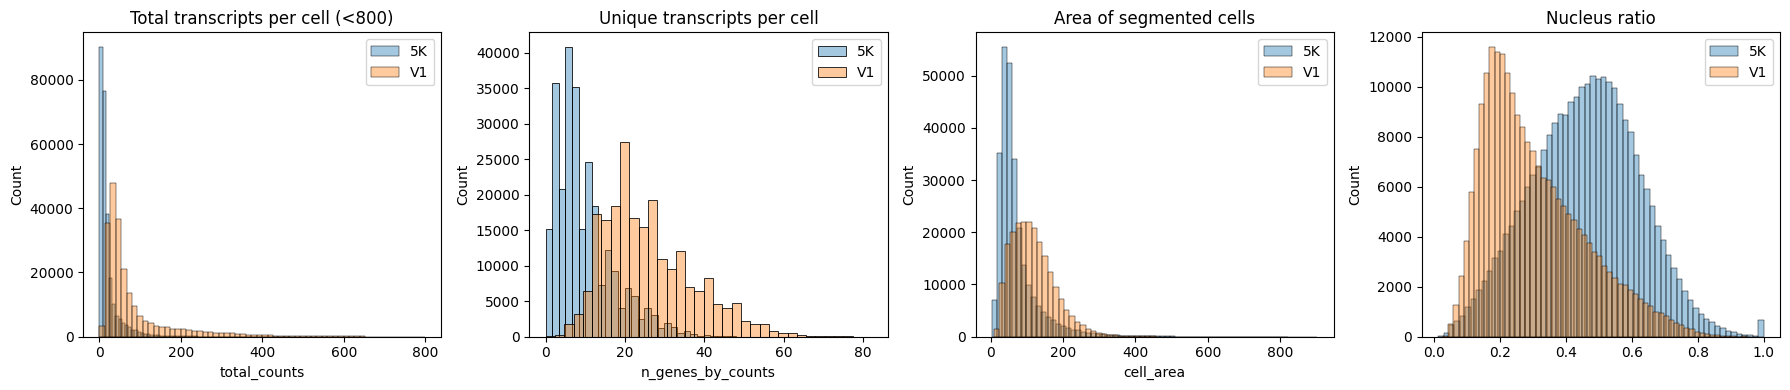

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))

# 1) Total transcripts per cell
axs[0].set_title("Total transcripts per cell (<800)")
sns.histplot(
    adata_5k.obs.loc[adata_5k.obs["total_counts"] < 800, "total_counts"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[0],
)
sns.histplot(
    adata_v1.obs.loc[adata_v1.obs["total_counts"] < 800, "total_counts"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[0],
)
axs[0].legend()

# 2) Unique transcripts per cell
axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata_5k.obs["n_genes_by_counts"],
    kde=False,
    bins=35,
    alpha=0.4,
    label="5K",
    ax=axs[1],
)
sns.histplot(
    adata_v1.obs["n_genes_by_counts"],
    kde=False,
    bins=35,
    alpha=0.4,
    label="V1",
    ax=axs[1],
)
axs[1].legend()

# 3) Area of segmented cells
axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata_5k.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[2],
)
sns.histplot(
    adata_v1.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[2],
)
axs[2].legend()

# 4) Nucleus ratio
axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata_5k.obs["nucleus_area"] / adata_5k.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[3],
)
sns.histplot(
    adata_v1.obs["nucleus_area"] / adata_v1.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[3],
)
axs[3].legend()

plt.tight_layout()
plt.show()

### How I read the Quality Control plot above
The overlaid histograms compare per-cell distributions between 5K and V1 using all genes.
- A right-shift in **total_counts** or **n_genes_by_counts** suggests higher effective sensitivity.
- Differences in **cell_area** or **nucleus ratio** can indicate segmentation or morphology effects, not only chemistry effects.

## Per-gene statistics

### Interpreting the data
Here is what the `adata_5k.var` columns mean. The first three come from the Xenium cell-feature matrix feature annotations; the rest are per-gene QC metrics added by `sc.pp.calculate_qc_metrics`.
- `gene_ids`: Ensembl gene ID for the feature (matches column 1 of Xenium `cell_feature_matrix/features.tsv.gz`).
- `feature_types`: Feature category (e.g., Gene Expression; corresponds to column 3 of `features.tsv.gz`).
- `genome`: Genome/reference label stored in 10x matrices (often empty or a single reference label for Xenium targeted panels).
- `n_cells_by_counts`: Number of cells with nonzero counts for the gene (detected in at least one transcript).
- `mean_counts`: Mean expression across all cells (including zeros) from the matrix used for QC (`adata.X` unless another layer/raw was specified).
- `log1p_mean_counts`: `log(1 + mean_counts)`; populated because `calculate_qc_metrics(log1p=True)` is default.
- `pct_dropout_by_counts`: Percentage of cells where the gene has zero counts (dropout rate).
- `total_counts`: Sum of counts for the gene across all cells (total transcripts assigned to that gene in the matrix).
- `log1p_total_counts`: `log(1 + total_counts)`; also added due to `log1p=True`.

In [16]:
adata_5k.var

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ACE,ENSG00000159640,Gene Expression,,17279,0.101490,0.096664,93.539015,27142.0,10.208875
ACE2,ENSG00000130234,Gene Expression,,7459,0.035179,0.034574,97.210921,9408.0,9.149422
ADAM17,ENSG00000151694,Gene Expression,,28215,0.129541,0.121812,89.449812,34644.0,10.452909
ADAM28,ENSG00000042980,Gene Expression,,9867,0.044014,0.043073,96.310519,11771.0,9.373479
ADAMTS1,ENSG00000154734,Gene Expression,,50225,0.674419,0.515466,81.219806,180364.0,12.102737
...,...,...,...,...,...,...,...,...,...
UPK3B,ENSG00000243566,Gene Expression,,1191,0.004782,0.004771,99.554660,1279.0,7.154615
VSIG4,ENSG00000155659,Gene Expression,,8115,0.050307,0.049083,96.965629,13454.0,9.507106
WFS1,ENSG00000109501,Gene Expression,,10140,0.043012,0.042113,96.208439,11503.0,9.350451
WNT2,ENSG00000105989,Gene Expression,,3374,0.014074,0.013976,98.738390,3764.0,8.233503


## Per-gene detection

Each point is one overlap gene after applying the ≥1% expressing-in-either-panel filter.
- Left plot (detection sensitivity): 
    - Each point represents a gene
    - x-axis is the % of cells that have a > 0 count for custom V1 panel
    - y-axis is the % of cells that have a > 0 count for 5K panel
- Right panel (magnitude when detected): 
    - Each point is a gene again, but we're only looking at data for cells where the gene was detected (count>0), and averaging these raw coutns across the cells
    - x-axis is the mean raw counts among expressing V1 cells (total_counts / n_cells_by_counts); 
    - x-axis is the same for 5K. 

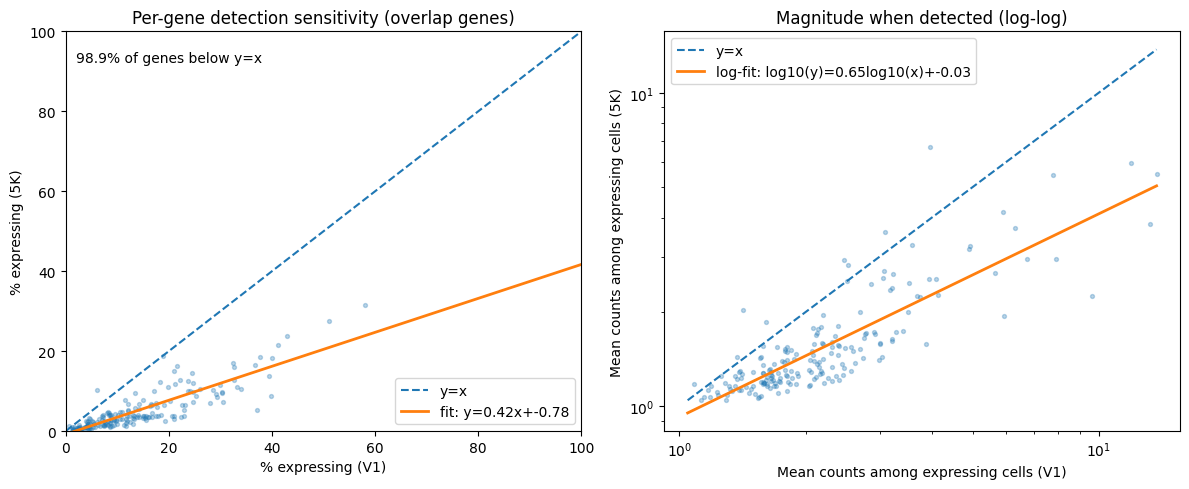

In [31]:
# We make a new data fram, from which we do the plotting
min_pct = 1.0 # Minimum of %1 expresison to be included in the plots
d = pd.DataFrame(index=adata_5k.var_names)
d["pct_expressing_5k"] = 100 - adata_5k.var["pct_dropout_by_counts"]
d["pct_expressing_v1"] = 100 - adata_v1.var["pct_dropout_by_counts"]
d["n_cells_5k"] = adata_5k.var["n_cells_by_counts"]
d["n_cells_v1"] = adata_v1.var["n_cells_by_counts"]
d["mean_pos_counts_5k"] = adata_5k.var["total_counts"] / d["n_cells_5k"].replace(0, np.nan)
d["mean_pos_counts_v1"] = adata_v1.var["total_counts"] / d["n_cells_v1"].replace(0, np.nan)

# Apply 1% expressing filter in either panel
mask = (d["pct_expressing_5k"] >= min_pct) | (d["pct_expressing_v1"] >= min_pct)
d = d.loc[mask].copy()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1) Detection sensitivity (% expressing)
x = d["pct_expressing_v1"].to_numpy()
y = d["pct_expressing_5k"].to_numpy()

axs[0].scatter(x, y, s=8, alpha=0.3)
axs[0].plot([0, 100], [0, 100], linestyle="--", label="y=x")

# Linear fit in original scale
valid_lin = np.isfinite(x) & np.isfinite(y)
if valid_lin.sum() >= 2:
    m, b = np.polyfit(x[valid_lin], y[valid_lin], 1)
    x_line = np.linspace(0, 100, 200)
    y_line = m * x_line + b
    axs[0].plot(x_line, y_line, linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

axs[0].set_xlim(0, 100)
axs[0].set_ylim(0, 100)
axs[0].set_xlabel("% expressing (V1)")
axs[0].set_ylabel("% expressing (5K)")
axs[0].set_title("Per-gene detection sensitivity (overlap genes)")

below = np.mean(y < x) * 100
axs[0].text(2, 95, f"{below:.1f}% of genes below y=x", va="top")
axs[0].legend()

# 2) Mean among expressing cells (raw counts)
x2 = d["mean_pos_counts_v1"].to_numpy()
y2 = d["mean_pos_counts_5k"].to_numpy()

# log scale is usually necessary because these span orders of magnitude
axs[1].scatter(x2, y2, s=8, alpha=0.3)
lo = np.nanmin([x2[x2 > 0].min(), y2[y2 > 0].min()])
hi = np.nanmax([x2.max(), y2.max()])
axs[1].plot([lo, hi], [lo, hi], linestyle="--", label="y=x")

# Linear fit in log10-space, then transformed back
valid_log = np.isfinite(x2) & np.isfinite(y2) & (x2 > 0) & (y2 > 0)
if valid_log.sum() >= 2:
    lx = np.log10(x2[valid_log])
    ly = np.log10(y2[valid_log])
    m_log, b_log = np.polyfit(lx, ly, 1)
    x_fit = np.logspace(np.log10(lo), np.log10(hi), 200)
    y_fit = 10 ** (m_log * np.log10(x_fit) + b_log)
    axs[1].plot(x_fit, y_fit, linewidth=2, label=f"log-fit: log10(y)={m_log:.2f}log10(x)+{b_log:.2f}")

axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel("Mean counts among expressing cells (V1)")
axs[1].set_ylabel("Mean counts among expressing cells (5K)")
axs[1].set_title("Magnitude when detected (log-log)")
axs[1].legend()

plt.tight_layout()
plt.show()

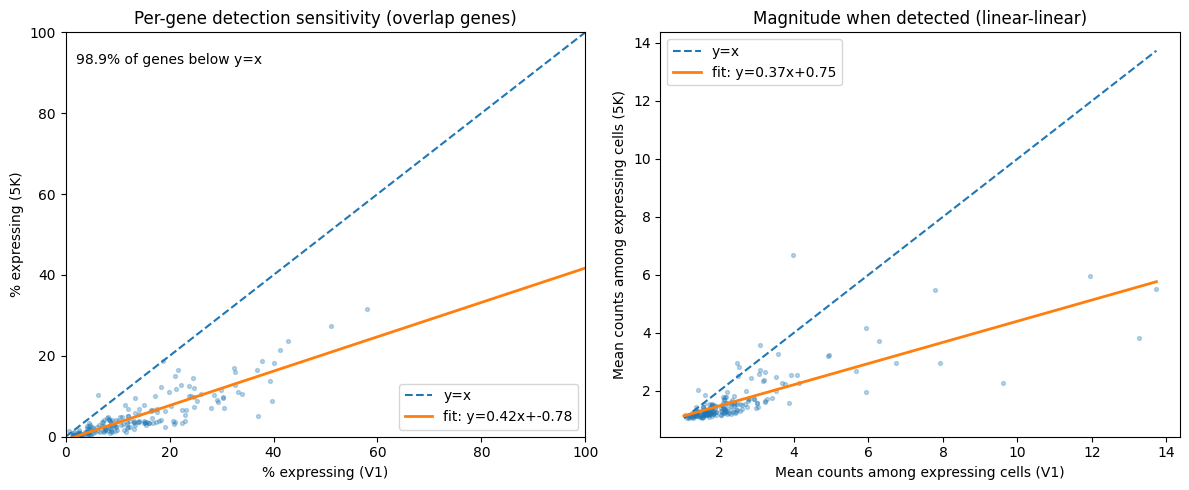

In [ ]:
# Linear-space copy: right panel uses linear magnitude space (not log-space)
min_pct = 1.0 # Minimum of %1 expresison to be included in the plots
d = pd.DataFrame(index=adata_5k.var_names)
d["pct_expressing_5k"] = 100 - adata_5k.var["pct_dropout_by_counts"]
d["pct_expressing_v1"] = 100 - adata_v1.var["pct_dropout_by_counts"]
d["n_cells_5k"] = adata_5k.var["n_cells_by_counts"]
d["n_cells_v1"] = adata_v1.var["n_cells_by_counts"]
d["mean_pos_counts_5k"] = adata_5k.var["total_counts"] / d["n_cells_5k"].replace(0, np.nan)
d["mean_pos_counts_v1"] = adata_v1.var["total_counts"] / d["n_cells_v1"].replace(0, np.nan)

# Apply 1% expressing filter in either panel
mask = (d["pct_expressing_5k"] >= min_pct) | (d["pct_expressing_v1"] >= min_pct)
d = d.loc[mask].copy()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1) Detection sensitivity (% expressing)
x = d["pct_expressing_v1"].to_numpy()
y = d["pct_expressing_5k"].to_numpy()

axs[0].scatter(x, y, s=8, alpha=0.3)
axs[0].plot([0, 100], [0, 100], linestyle="--", label="y=x")

# Linear fit in original scale
valid_lin = np.isfinite(x) & np.isfinite(y)
if valid_lin.sum() >= 2:
    m, b = np.polyfit(x[valid_lin], y[valid_lin], 1)
    x_line = np.linspace(0, 100, 200)
    y_line = m * x_line + b
    axs[0].plot(x_line, y_line, linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

axs[0].set_xlim(0, 100)
axs[0].set_ylim(0, 100)
axs[0].set_xlabel("% expressing (V1)")
axs[0].set_ylabel("% expressing (5K)")
axs[0].set_title("Per-gene detection sensitivity (overlap genes)")

below = np.mean(y < x) * 100
axs[0].text(2, 95, f"{below:.1f}% of genes below y=x", va="top")
axs[0].legend()

# 2) Mean among expressing cells (raw counts, linear-linear)
x2 = d["mean_pos_counts_v1"].to_numpy()
y2 = d["mean_pos_counts_5k"].to_numpy()

axs[1].scatter(x2, y2, s=8, alpha=0.3)

valid_mag = np.isfinite(x2) & np.isfinite(y2)
if valid_mag.sum() >= 2:
    lo_lin = np.nanmin([x2[valid_mag].min(), y2[valid_mag].min()])
    hi_lin = np.nanmax([x2[valid_mag].max(), y2[valid_mag].max()])
    axs[1].plot([lo_lin, hi_lin], [lo_lin, hi_lin], linestyle="--", label="y=x")

    m2, b2 = np.polyfit(x2[valid_mag], y2[valid_mag], 1)
    x2_line = np.linspace(lo_lin, hi_lin, 200)
    y2_line = m2 * x2_line + b2
    axs[1].plot(x2_line, y2_line, linewidth=2, label=f"fit: y={m2:.2f}x+{b2:.2f}")

    # Cap axes to emphasize dense region in linear space
    cap_q = 0.99
    x_cap = np.nanquantile(x2[valid_mag], cap_q)
    y_cap = np.nanquantile(y2[valid_mag], cap_q)
    axs[1].set_xlim(0, x_cap * 1.05)
    axs[1].set_ylim(0, y_cap * 1.05)

axs[1].set_xlabel("Mean counts among expressing cells (V1)")
axs[1].set_ylabel("Mean counts among expressing cells (5K)")
axs[1].set_title("Magnitude when detected (linear-linear, 99% axis cap)")
axs[1].legend()

plt.tight_layout()
plt.show()

### Finding biggest mean differences
Here we find the top 3 biggest mean differences and top 3 lowest mean differences between genes for the 5K and V1 panel

In [ ]:
# Top/bottom 3 genes by mean_counts difference (V1 - 5K)
means = pd.DataFrame({
    "mean_counts_5k": adata_5k.var["mean_counts"],
    "mean_counts_v1": adata_v1.var.loc[adata_5k.var_names, "mean_counts"],
})
means["mean_diff_v1_minus_5k"] = means["mean_counts_v1"] - means["mean_counts_5k"]

# Highest positive differences
high5 = means.sort_values("mean_diff_v1_minus_5k", ascending=False).head(5)
# Most negative differences
low3 = means.sort_values("mean_diff_v1_minus_5k", ascending=True).head(3)

print("Top 5 higher in V1 vs 5K (mean_counts):")
print(high5)
print("\nTop 3 lower in V1 vs 5K (mean_counts):")
print(low3)


Top 5 higher in 5K vs V1 (mean_counts):
         mean_counts_5k  mean_counts_v1  mean_diff_5k_minus_v1
MUC1           0.697064        5.304090               4.607027
CDH1           1.184321        5.665051               4.480731
EPCAM          1.412031        5.125669               3.713637
AGR3           0.290376        3.133461               2.843085
TMPRSS2        0.491905        2.909765               2.417861

Top 3 lower in 5K vs V1 (mean_counts):
         mean_counts_5k  mean_counts_v1  mean_diff_5k_minus_v1
CLDN5          0.210151        0.087169              -0.122982
ADAMTS1        0.674419        0.581453              -0.092966
MMP12          0.108624        0.099188              -0.009436


### Means of the expressing cells

In [19]:
means_pos = pd.DataFrame(index=adata_5k.var_names)

# Mean among expressing cells (nonzero only)
means_pos["mean_pos_counts_5k"] = (
    adata_5k.var["total_counts"] / adata_5k.var["n_cells_by_counts"].replace(0, np.nan)
).astype(float)

means_pos["mean_pos_counts_v1"] = (
    adata_v1.var["total_counts"] / adata_v1.var["n_cells_by_counts"].replace(0, np.nan)
).astype(float)

means_pos["mean_pos_diff_5k_minus_v1"] = (
    means_pos["mean_pos_counts_5k"] - means_pos["mean_pos_counts_v1"]
)

# Drop genes that are never expressed in either dataset (optional but usually sensible)
means_pos = means_pos.dropna(subset=["mean_pos_counts_5k", "mean_pos_counts_v1"])

high3_pos = means_pos.sort_values("mean_pos_diff_5k_minus_v1", ascending=False).head(3)
low3_pos  = means_pos.sort_values("mean_pos_diff_5k_minus_v1", ascending=True).head(3)

print("Top 3 higher in 5K vs V1 (mean among expressing cells):")
print(high3_pos)

print("\nTop 3 lower in 5K vs V1 (mean among expressing cells):")
print(low3_pos)

Top 3 higher in 5K vs V1 (mean among expressing cells):
         mean_pos_counts_5k  mean_pos_counts_v1  mean_pos_diff_5k_minus_v1
MMP12              6.692006            3.967872                   2.724134
CLDN5              2.036600            1.419475                   0.617124
ADAMTS1            3.591120            3.091854                   0.499266

Top 3 lower in 5K vs V1 (mean among expressing cells):
      mean_pos_counts_5k  mean_pos_counts_v1  mean_pos_diff_5k_minus_v1
MUC1            3.822589           13.259252                  -9.436664
CDH1            5.493920           13.731065                  -8.237145
AGR3            2.251645            9.616321                  -7.364675


Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.6971       5.3041           18.2354            40.0029
   CDH1      1.1843       5.6651           21.5569            41.2572
  EPCAM      1.4120       5.1257           23.6801            42.8836
   AGR3      0.2904       3.1335           12.8962            32.5848
TMPRSS2      0.4919       2.9098           16.6144            36.7725
  CLDN5      0.2102       0.0872           10.3187             6.1409
ADAMTS1      0.6744       0.5815           18.7802            18.8060
  MMP12      0.1086       0.0992            1.6232             2.4998


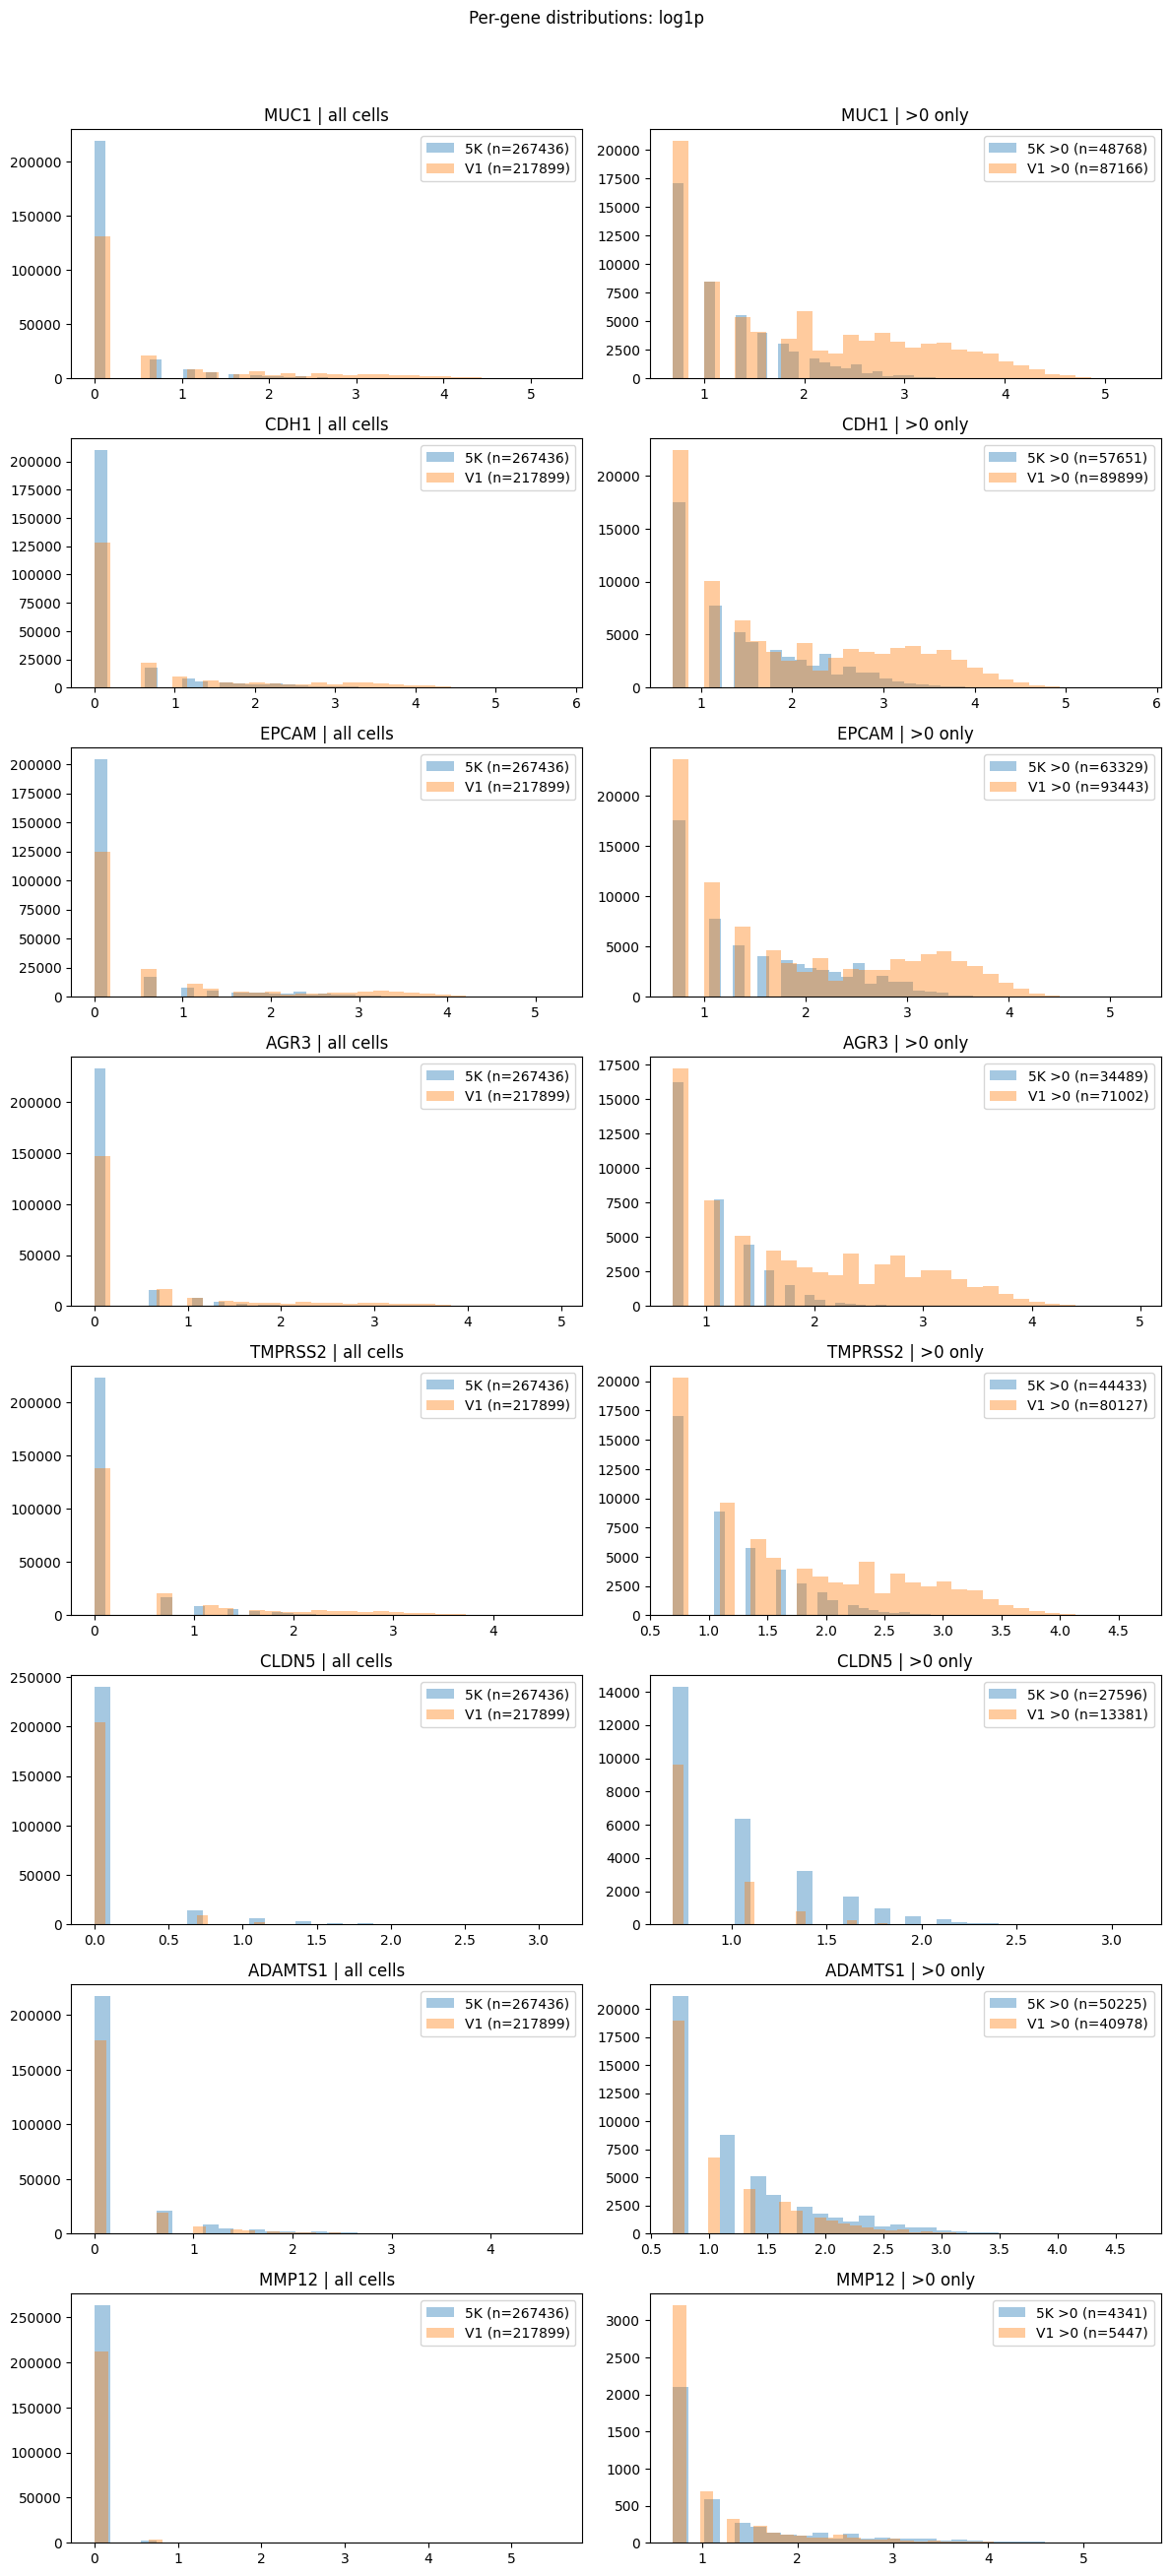

In [20]:
# This helps since we have a very sparse expression matrix, which converts it to an array
def _col_dense(X, j):
    if issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X)[:, j]

# Same thing but for rows
def _row_sums(X):
    if issparse(X):
        return np.ravel(X.sum(axis=1)).astype(float)
    return np.asarray(X).sum(axis=1).astype(float)

def plot_gene_hist_grid(
    adata_5k, adata_v1,
    genes,
    target_sum=1e4,
    bins=30,
    seed=0,
    density=False
):
    X5, Xv = adata_5k.X, adata_v1.X
    tot5, totv = _row_sums(X5), _row_sums(Xv)

    n = len(genes)
    fig, axs = plt.subplots(n, 2, figsize=(12, 3.2 * n), squeeze=False)

    rng = np.random.default_rng(seed)
    summary_rows = []

    for i, gene in enumerate(genes):
        j5 = adata_5k.var_names.get_loc(gene)
        jv = adata_v1.var_names.get_loc(gene)

        c5 = _col_dense(X5, j5)
        cv = _col_dense(Xv, jv)

        x5_all = np.log1p(c5)
        xv_all = np.log1p(cv)

        # >0 only
        x5_pos = x5_all[c5 > 0]
        xv_pos = xv_all[cv > 0]

        summary_rows.append(
            {
                "gene": gene,
                "mean_first": float(np.mean(c5)),
                "mean_second": float(np.mean(cv)),
                "detect_pct_first": float(np.mean(c5 > 0) * 100),
                "detect_pct_second": float(np.mean(cv > 0) * 100),
            }
        )

        # Left: all cells (zeros included)
        axL = axs[i, 0]
        axL.hist(x5_all, bins=bins, density=density, alpha=0.4, label=f"5K (n={len(x5_all)})")
        axL.hist(xv_all, bins=bins, density=density, alpha=0.4, label=f"V1 (n={len(xv_all)})")
        axL.set_title(f"{gene} | all cells")
        axL.legend()

        # Right: positives only
        axR = axs[i, 1]
        axR.hist(x5_pos, bins=bins, density=density, alpha=0.4, label=f"5K >0 (n={len(x5_pos)})")
        axR.hist(xv_pos, bins=bins, density=density, alpha=0.4, label=f"V1 >0 (n={len(xv_pos)})")
        axR.set_title(f"{gene} | >0 only")
        axR.legend()

    summary_df = pd.DataFrame(summary_rows)
    print("Per-gene summary (mean counts + detection %):")
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig.suptitle("Per-gene distributions: log1p", y=1.02)
    plt.tight_layout()
    plt.show()

# Example usage:
genes_to_plot = list(high5.index) + list(low3.index)
plot_gene_hist_grid(adata_5k, adata_v1, genes_to_plot, bins=30, density=False)

## Downsampling (via bionomial thinning)

> Goal: transform the V1 counts so they are **5K-like** on the overlap genes, while only removing counts (never inventing new counts).

How `thin_v1_to_match_5k_det_and_meanpos` works:
1. It assumes `adata_v1` and `adata_5k` have the same overlap genes in the same order.
2. For each gene, it computes a 5K target detection fraction:
   - target detected cells in V1 size = `round((n_cells_by_counts_5k / n_obs_5k) * n_obs_v1)`.
3. It keeps at most that many V1-expressing cells for the gene (randomly if V1 has more).
4. For the kept positive cells, it adjusts per-cell counts with binomial thinning to match 5K mean among expressing cells:
   - if source count is `x`, new count is `1 + Binomial(x-1, p)` so positives stay positive.
   - `p` is chosen from source/target positive means and clipped to `[0, 1]`.
5. It repeats this per gene and rebuilds a sparse matrix for `adata_v1_5k_like`.

Why this is useful here:
- Detection is matched by limiting how many cells remain positive per gene.
- Magnitude among positive cells is matched by thinning counts inside those positive cells.
- It is conservative: thinning can only decrease counts, so impossible targets are approached as closely as allowed by that constraint.

In [21]:
def thin_v1_to_match_5k_det_and_meanpos(adata_v1, adata_5k, seed=0):
    """
    Overlap-only, same var order.
    Produces a V1-downsampled matrix that matches:
      - per-gene detection rate (fraction >0) to 5K (when possible)
      - per-gene mean among expressing cells to 5K (when possible)
    """
    assert (adata_v1.var_names == adata_5k.var_names).all(), "Genes must match and be in same order."
    rng = np.random.default_rng(seed)

    X = adata_v1.X
    X = X.tocsc() if sp.issparse(X) else sp.csc_matrix(X)
    n_cells, n_genes = X.shape

    # Targets from 5K
    n_expr_5k = adata_5k.var["n_cells_by_counts"].to_numpy(dtype=int)
    det_tgt = n_expr_5k / float(adata_5k.n_obs)
    k_tgt = np.rint(det_tgt * n_cells).astype(int)

    meanpos_5k = (adata_5k.var["total_counts"] / adata_5k.var["n_cells_by_counts"].replace(0, np.nan)).to_numpy()
    meanpos_5k = np.nan_to_num(meanpos_5k, nan=0.0)

    # Source mean among positives from V1 (used to set p)
    n_expr_v1 = adata_v1.var["n_cells_by_counts"].to_numpy(dtype=int)
    meanpos_v1 = (adata_v1.var["total_counts"] / adata_v1.var["n_cells_by_counts"].replace(0, np.nan)).to_numpy()
    meanpos_v1 = np.nan_to_num(meanpos_v1, nan=0.0)

    new_data_chunks = []
    new_indices_chunks = []
    new_indptr = np.zeros(n_genes + 1, dtype=X.indptr.dtype)
    nnz_so_far = 0

    for j in range(n_genes):
        start, end = X.indptr[j], X.indptr[j + 1]
        idx = X.indices[start:end]
        dat = X.data[start:end].astype(int)
        nnz = dat.size

        if nnz == 0 or k_tgt[j] == 0:
            new_indptr[j + 1] = nnz_so_far
            continue

        # Step A: match detection (cannot increase)
        k_keep = min(nnz, k_tgt[j])
        if k_keep < nnz:
            keep = rng.choice(nnz, size=k_keep, replace=False)
            idx_k = idx[keep]
            dat_k = dat[keep]
        else:
            idx_k = idx
            dat_k = dat

        # Step B: match mean among positives without creating new zeros
        m_src = meanpos_v1[j]
        m_tgt = meanpos_5k[j]

        if m_tgt <= 1.0:
            # if 5K positives average ~1, force to 1
            dat_k = np.ones_like(dat_k)
        elif m_src <= 1.0:
            # can't thin below 1 and can't increase by thinning
            dat_k = np.ones_like(dat_k)
        else:
            p = (m_tgt - 1.0) / (m_src - 1.0)
            p = float(np.clip(p, 0.0, 1.0))
            if p < 1.0:
                dat_k = 1 + rng.binomial(dat_k - 1, p)

        # sort indices
        order = np.argsort(idx_k)
        idx_k = idx_k[order]
        dat_k = dat_k[order]

        new_indices_chunks.append(idx_k.astype(X.indices.dtype, copy=False))
        new_data_chunks.append(dat_k.astype(X.data.dtype, copy=False))

        nnz_so_far += idx_k.size
        new_indptr[j + 1] = nnz_so_far

    new_indices = np.concatenate(new_indices_chunks) if new_indices_chunks else np.array([], dtype=X.indices.dtype)
    new_data = np.concatenate(new_data_chunks) if new_data_chunks else np.array([], dtype=X.data.dtype)

    X_new = sp.csc_matrix((new_data, new_indices, new_indptr), shape=X.shape).tocsr()

    adata_ds = adata_v1.copy()
    adata_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_ds, inplace=True, percent_top=None)
    return adata_ds

In [22]:
adata_v1_5k_like = thin_v1_to_match_5k_det_and_meanpos(adata_v1, adata_5k, seed=0)
sc.pp.calculate_qc_metrics(adata_v1_5k_like, inplace=True, percent_top=None)

Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.6971       0.6987           18.2354            18.2355
   CDH1      1.1843       1.1820           21.5569            21.5568
  EPCAM      1.4120       1.4058           23.6801            23.6802
   AGR3      0.2904       0.2908           12.8962            12.8963
TMPRSS2      0.4919       0.4895           16.6144            16.6146
  CLDN5      0.2102       0.0872           10.3187             6.1409
ADAMTS1      0.6744       0.5808           18.7802            18.7803
  MMP12      0.1086       0.0632            1.6232             1.6232


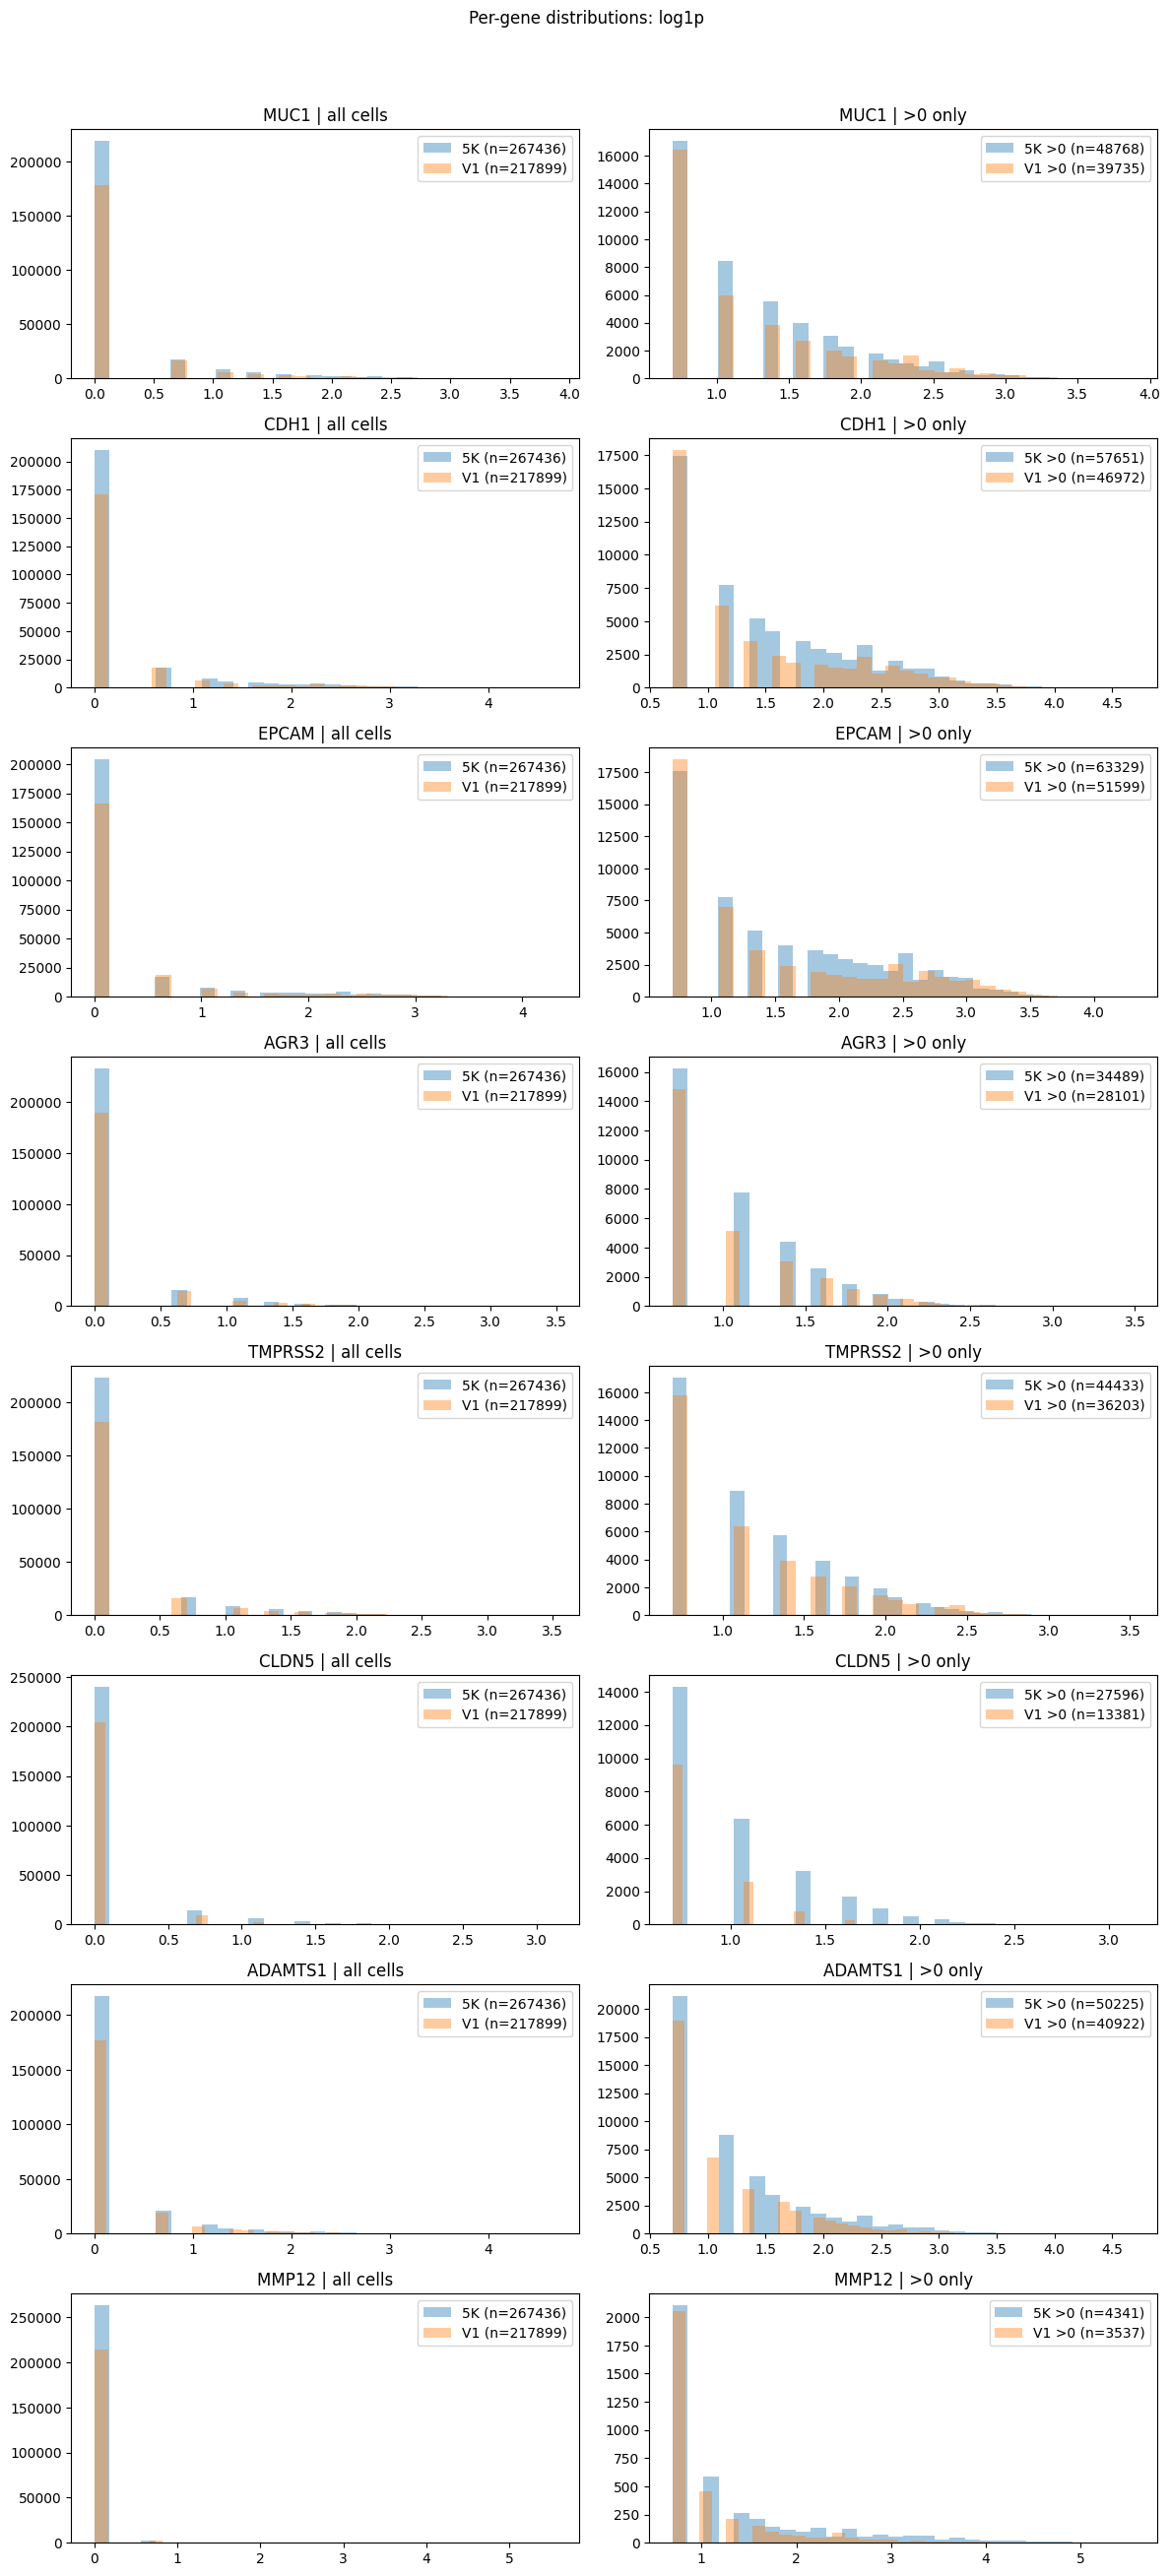

In [23]:
genes_to_plot = list(high5.index) + list(low3.index)
plot_gene_hist_grid(adata_5k, adata_v1_5k_like , genes_to_plot, bins=30, density=False)

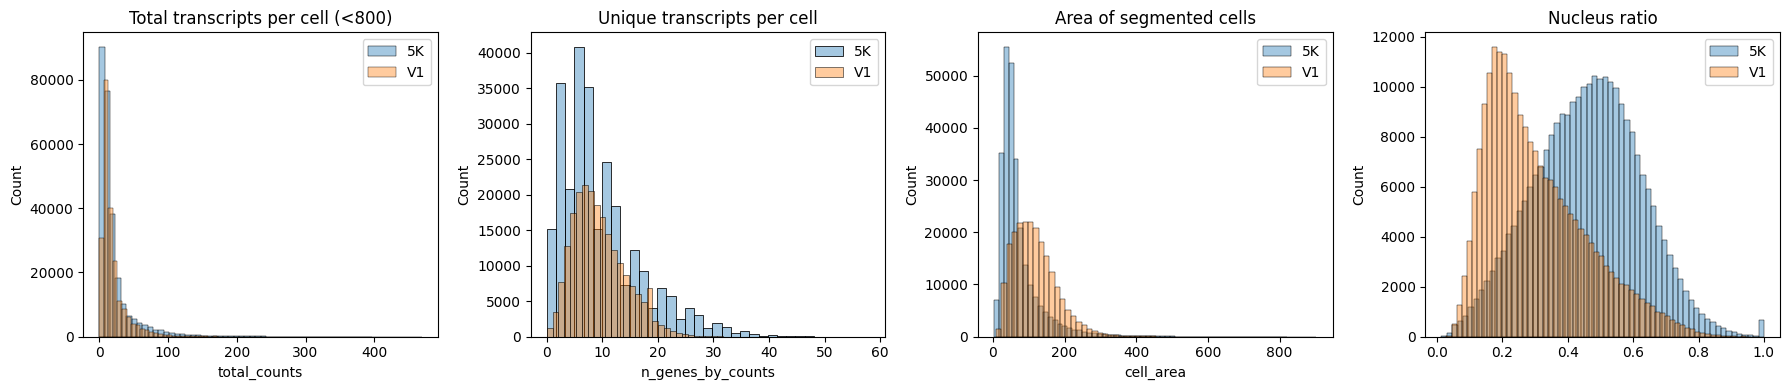

In [24]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))

# 1) Total transcripts per cell
axs[0].set_title("Total transcripts per cell (<800)")
sns.histplot(
    adata_5k.obs.loc[adata_5k.obs["total_counts"] < 800, "total_counts"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[0],
)
sns.histplot(
    adata_v1_5k_like.obs.loc[adata_v1_5k_like.obs["total_counts"] < 800, "total_counts"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[0],
)
axs[0].legend()

# 2) Unique transcripts per cell
axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata_5k.obs["n_genes_by_counts"],
    kde=False,
    bins=35,
    alpha=0.4,
    label="5K",
    ax=axs[1],
)
sns.histplot(
    adata_v1_5k_like.obs["n_genes_by_counts"],
    kde=False,
    bins=35,
    alpha=0.4,
    label="V1",
    ax=axs[1],
)
axs[1].legend()

# 3) Area of segmented cells
axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata_5k.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[2],
)
sns.histplot(
    adata_v1_5k_like.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[2],
)
axs[2].legend()

# 4) Nucleus ratio
axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata_5k.obs["nucleus_area"] / adata_5k.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="5K",
    ax=axs[3],
)
sns.histplot(
    adata_v1_5k_like.obs["nucleus_area"] / adata_v1_5k_like.obs["cell_area"],
    kde=False,
    bins=60,
    alpha=0.4,
    label="V1",
    ax=axs[3],
)
axs[3].legend()

plt.tight_layout()
plt.show()

## Subsampling transcripts based on this new AnnData

is this actually necessary? 

In [25]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import scipy.sparse as sp
import spatialdata as sd

from pandas.util import hash_pandas_object
from spatialdata.models import PointsModel
from spatialdata.transformations import get_transformation, set_transformation

def make_sdata_with_thinned_transcripts(
    sdata_v1,
    adata_v1_5k_like,
    transcripts_key="transcripts_overlap",           # use what exists in sdata_v1.points
    out_points_key="transcripts_5k_like",
    out_table_key="table_5k_like",
    seed=0,
    shuffle_npartitions=None,
):
    if transcripts_key not in sdata_v1.points:
        raise KeyError(f"{transcripts_key=} not found. Available: {list(sdata_v1.points.keys())}")

    tx = sdata_v1.points[transcripts_key]
    if isinstance(tx, pd.DataFrame):
        tx = dd.from_pandas(tx, npartitions=max(1, tx.shape[0] // 2_000_000 + 1))

    if shuffle_npartitions is None:
        shuffle_npartitions = tx.npartitions

    cell_id_usable = False
    if "cell_id" in tx.columns and "cell_id" in adata_v1_5k_like.obs.columns:
        tx_cell = tx["cell_id"].astype(str)
        n_non_empty = int((tx_cell.str.len() > 0).sum().compute())
        cell_id_usable = n_non_empty > 0

    if not cell_id_usable:
        raise ValueError(
            "Cannot build thinned transcripts: transcript cell_id is missing/unusable "
            "or absent from adata_v1_5k_like.obs."
        )

    print("Building transcripts_5k_like using cell_id + feature_name matching.")

    cell_ids = adata_v1_5k_like.obs["cell_id"].astype(str).to_numpy()
    gene_names = adata_v1_5k_like.var_names.astype(str).to_numpy()

    cell_map = pd.DataFrame({"cell_id": cell_ids, "cell_ix": np.arange(len(cell_ids), dtype=np.int32)})
    gene_map = pd.DataFrame({"feature_name": gene_names, "gene_ix": np.arange(len(gene_names), dtype=np.int32)})

    X = adata_v1_5k_like.X
    X = X.tocoo() if sp.issparse(X) else sp.coo_matrix(X)

    tgt = pd.DataFrame(
        {
            "cell_ix": X.row.astype(np.int32, copy=False),
            "gene_ix": X.col.astype(np.int32, copy=False),
            "target_n": X.data.astype(np.int32, copy=False),
        }
    )
    tgt = tgt[tgt["target_n"] > 0]
    tgt_dd = dd.from_pandas(tgt, npartitions=max(1, int(len(tgt) // 2_000_000) + 1))

    tx = tx.assign(
        cell_id=tx["cell_id"].astype(str),
        feature_name=tx["feature_name"].astype(str),
    )
    tx = tx.merge(dd.from_pandas(cell_map, npartitions=1), on="cell_id", how="inner")
    tx = tx.merge(dd.from_pandas(gene_map, npartitions=1), on="feature_name", how="inner")
    tx = tx.merge(tgt_dd, on=["cell_ix", "gene_ix"], how="inner")

    meta_with_rand = tx._meta.copy()
    meta_with_rand["_rand"] = np.float64(0.0)

    def _add_randkey(df, partition_info=None):
        df = df.copy()
        h = hash_pandas_object(df["transcript_id"], index=False).astype("uint64").to_numpy()
        h ^= np.uint64(seed)
        df["_rand"] = (h % np.uint64(2**53)).astype("float64") / float(2**53)
        return df

    tx = tx.map_partitions(_add_randkey, meta=meta_with_rand)
    tx = tx.shuffle(on=["cell_ix", "gene_ix"], shuffle="tasks", npartitions=shuffle_npartitions)

    meta_no_rand = tx._meta.drop(columns=["_rand"])

    def _take_topn_cell_gene(df):
        df = df.sort_values(["cell_ix", "gene_ix", "_rand"])
        df["_rank"] = df.groupby(["cell_ix", "gene_ix"]).cumcount()
        out = df[df["_rank"] < df["target_n"]]
        return out.drop(columns=["_rand", "_rank"])

    tx_keep = tx.map_partitions(_take_topn_cell_gene, meta=meta_no_rand)
    drop_cols = [c for c in ["cell_ix", "gene_ix", "target_n"] if c in tx_keep.columns]
    tx_keep = tx_keep.drop(columns=drop_cols)

    tx_keep = PointsModel.parse(tx_keep)
    t = get_transformation(sdata_v1.points[transcripts_key], to_coordinate_system="global")
    set_transformation(tx_keep, t, to_coordinate_system="global")

    points = dict(sdata_v1.points)
    points[out_points_key] = tx_keep

    tables = dict(sdata_v1.tables)
    tables[out_table_key] = adata_v1_5k_like

    return sd.SpatialData(
        images=dict(sdata_v1.images),
        labels=dict(sdata_v1.labels),
        points=points,
        shapes=dict(sdata_v1.shapes),
        tables=tables,
        attrs=sdata_v1.attrs,
    )

In [26]:
# adata_v1_5k_like2 is your “works great” AnnData output
sdata_v1_5k_like = make_sdata_with_thinned_transcripts(
    sdata_v1,
    adata_v1_5k_like,
    transcripts_key="transcripts_overlap",
    out_points_key="transcripts_5k_like",
    out_table_key="table_5k_like",
    seed=0,
)

Building transcripts_5k_like using cell_id + feature_name matching.


c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\dask\dataframe\multi.py:169: UserWarning: Merging dataframes with merge column data type mismatches: 
+------------------------+------------+-------------+
| Merge columns          | left dtype | right dtype |
+------------------------+------------+-------------+
| ('cell_id', 'cell_id') | object     | string      |
+------------------------+------------+-------------+
Cast dtypes explicitly to avoid unexpected results.
  warnings.warn(
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\dask\dataframe\multi.py:169: UserWarning: Merging dataframes with merge column data type mismatches: 
+----------------------------------+------------+-------------+
| Merge columns                    | left dtype | right dtype |
+----------------------------------+------------+-------------+
| ('feature_name', 'feature_name') | object     | string      |
+----------------------------------+------------+------

In [27]:
sdata_v1_5k_like

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 34191, 54061), (1, 17095, 27030), (1, 8547, 13515), (1, 4273, 6757), (1, 2136, 3378)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34191, 54061), (17095, 27030), (8547, 13515), (4273, 6757), (2136, 3378)
│     └── 'nucleus_labels': DataTree[yx] (34191, 54061), (17095, 27030), (8547, 13515), (4273, 6757), (2136, 3378)
├── Points
│     ├── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
│     ├── 'transcripts_5k_like': DataFrame with shape: (<Delayed>, 10) (3D points)
│     └── 'transcripts_overlap': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278659, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (217899, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (278659, 1) (2D shapes)
└── Tables
      ├── 'table': AnnData (217899, 196)
      └── 'table_5k_like': AnnData (217899, 196)
with coordinate 

In [28]:
keys_to_count = ["transcripts", "transcripts_5k_like", "transcripts_overlap"]
for key in keys_to_count:
    if key in sdata_v1_5k_like.points:
        n = sdata_v1_5k_like.points[key].shape[0]
        n = int(n.compute()) if hasattr(n, "compute") else int(n)
        print(f"{key}: {n:,} transcripts")
    else:
        print(f"{key}: not found in sdata_v1_5k_like.points")

transcripts: 30,890,718 transcripts
transcripts_5k_like: 4,148,385 transcripts
transcripts_overlap: 17,284,131 transcripts


In [29]:
tx_counts = (
    sdata_v1_5k_like.points["transcripts_5k_like"][["feature_name"]]
    .assign(feature_name=lambda d: d["feature_name"].astype(str))
    .groupby("feature_name")
    .size()
    .compute()
    .rename("tx_count")
)

tab = sdata_v1_5k_like.tables["table_5k_like"]
table_counts = pd.Series(
    np.ravel(np.asarray(tab.var["total_counts"])).astype(int),
    index=tab.var_names.astype(str),
    name="table_total",
)

cmp = pd.concat([table_counts, tx_counts], axis=1).fillna(0).astype(int)
cmp["diff_tx_minus_table"] = cmp["tx_count"] - cmp["table_total"]

print("Genes compared:", cmp.shape[0])
print("Exact matches:", int((cmp["diff_tx_minus_table"] == 0).sum()))
print("Max abs diff:", int(cmp["diff_tx_minus_table"].abs().max()))
print("Total table counts:", int(cmp["table_total"].sum()))
print("Total transcript counts:", int(cmp["tx_count"].sum()))
print("\nTop non-zero differences:")
print(cmp.loc[cmp["diff_tx_minus_table"] != 0].sort_values("diff_tx_minus_table", key=np.abs, ascending=False).head(10))

Genes compared: 196
Exact matches: 0
Max abs diff: 2569
Total table counts: 4216808
Total transcript counts: 4148385

Top non-zero differences:
         table_total  tx_count  diff_tx_minus_table
CTSL           87350     84781                -2569
CD14           70776     68460                -2316
ADAMTS1       126548    124355                -2193
CD68           89967     87962                -2005
CD3E           64062     62086                -1976
HIF1A         115627    113782                -1845
LTBP2          99892     98154                -1738
CTTN          193915    192313                -1602
MALL           84257     82688                -1569
CD4            58724     57195                -1529


In [ ]:
# Assignment coverage diagnostic before thinning validation
tx_ov = sdata_v1.points["transcripts_overlap"]
tab_ids = set(sdata_v1.tables["table"].obs["cell_id"].astype(str).tolist())

n_total = tx_ov.shape[0]
n_total = int(n_total.compute()) if hasattr(n_total, "compute") else int(n_total)

tx_valid = tx_ov.assign(cell_id=tx_ov["cell_id"].astype(str))
tx_valid = tx_valid[(tx_valid["cell_id"].str.len() > 0) & (tx_valid["cell_id"] != "nan") & (tx_valid["cell_id"] != "None")]
n_valid = tx_valid.shape[0]
n_valid = int(n_valid.compute()) if hasattr(n_valid, "compute") else int(n_valid)

tx_in_tab = tx_valid[tx_valid["cell_id"].isin(list(tab_ids))]
n_in_tab = tx_in_tab.shape[0]
n_in_tab = int(n_in_tab.compute()) if hasattr(n_in_tab, "compute") else int(n_in_tab)

print(f"transcripts_overlap total: {n_total:,}")
print(f"with non-empty cell_id: {n_valid:,} ({(n_valid / max(n_total,1))*100:.2f}%)")
print(f"with cell_id present in filtered table: {n_in_tab:,} ({(n_in_tab / max(n_total,1))*100:.2f}%)")

In [124]:
# Build an AnnData table directly from transcripts_5k_like and compare to table_5k_like
tx_key = "transcripts_5k_like"
table_key = "table_5k_like"
new_table_key = "table_from_transcripts_5k_like"

tab = sdata_v1_5k_like.tables[table_key]
tx = sdata_v1_5k_like.points[tx_key][["cell_id", "feature_name"]].assign(
    cell_id=lambda d: d["cell_id"].astype(str),
    feature_name=lambda d: d["feature_name"].astype(str),
)
tx = tx[
    (tx["cell_id"].str.len() > 0)
    & (tx["cell_id"] != "nan")
    & (tx["cell_id"] != "None")
]

# count transcripts per (cell_id, gene)
agg = tx.groupby(["cell_id", "feature_name"]).size().compute().rename("count").reset_index()

# align to table_5k_like axes
obs_cell_ids = tab.obs["cell_id"].astype(str).to_numpy()
var_genes = tab.var_names.astype(str).to_numpy()

cell_to_ix = pd.Series(np.arange(tab.n_obs, dtype=np.int32), index=obs_cell_ids)
gene_to_ix = pd.Series(np.arange(tab.n_vars, dtype=np.int32), index=var_genes)

agg["row"] = agg["cell_id"].map(cell_to_ix)
agg["col"] = agg["feature_name"].map(gene_to_ix)
agg = agg.dropna(subset=["row", "col"]).copy()

rows = agg["row"].to_numpy(dtype=np.int32, copy=False)
cols = agg["col"].to_numpy(dtype=np.int32, copy=False)
vals = agg["count"].to_numpy(dtype=np.int32, copy=False)

X_from_tx = sp.csr_matrix((vals, (rows, cols)), shape=tab.shape)
adata_from_tx = ad.AnnData(X=X_from_tx, obs=tab.obs.copy(), var=tab.var.copy())

# Keep spatial metadata so squidpy spatial plotting works
if "spatial" in tab.obsm:
    adata_from_tx.obsm["spatial"] = np.array(tab.obsm["spatial"], copy=True)
if "spatial" in tab.uns:
    adata_from_tx.uns["spatial"] = tab.uns["spatial"].copy()

# Save as new table in SpatialData
sdata_v1_5k_like.tables[new_table_key] = adata_from_tx

# Comparisons
gene_tx = np.ravel(adata_from_tx.X.sum(axis=0)).astype(np.int64)
gene_tab = np.ravel(tab.X.sum(axis=0)).astype(np.int64)
cell_tx = np.ravel(adata_from_tx.X.sum(axis=1)).astype(np.int64)
cell_tab = np.ravel(tab.X.sum(axis=1)).astype(np.int64)

gene_cmp = pd.DataFrame({
    "table_sum": gene_tab,
    "tx_table_sum": gene_tx,
}, index=tab.var_names.astype(str))
gene_cmp["diff_tx_minus_table"] = gene_cmp["tx_table_sum"] - gene_cmp["table_sum"]

cell_cmp = pd.DataFrame({
    "table_sum": cell_tab,
    "tx_table_sum": cell_tx,
}, index=tab.obs["cell_id"].astype(str))
cell_cmp["diff_tx_minus_table"] = cell_cmp["tx_table_sum"] - cell_cmp["table_sum"]

print(f"Added new table: {new_table_key}")
print(f"Shape: {adata_from_tx.shape}")

print("\nGene-level agreement")
print("Genes:", gene_cmp.shape[0])
print("Exact matches:", int((gene_cmp["diff_tx_minus_table"] == 0).sum()))
print("Max abs diff:", int(gene_cmp["diff_tx_minus_table"].abs().max()))
print("Total table counts:", int(gene_cmp["table_sum"].sum()))
print("Total transcript-derived counts:", int(gene_cmp["tx_table_sum"].sum()))

print("\nTop 10 gene differences")
print(gene_cmp.loc[gene_cmp["diff_tx_minus_table"] != 0].sort_values("diff_tx_minus_table", key=np.abs, ascending=False).head(10))

print("\nCell-level agreement")
print("Cells:", cell_cmp.shape[0])
print("Exact matches:", int((cell_cmp["diff_tx_minus_table"] == 0).sum()))
print("Max abs diff:", int(cell_cmp["diff_tx_minus_table"].abs().max()))
print("Total table counts:", int(cell_cmp["table_sum"].sum()))
print("Total transcript-derived counts:", int(cell_cmp["tx_table_sum"].sum()))

print("\nTop 10 cell differences")
print(cell_cmp.loc[cell_cmp["diff_tx_minus_table"] != 0].sort_values("diff_tx_minus_table", key=np.abs, ascending=False).head(10))

Added new table: table_from_transcripts_5k_like
Shape: (217899, 196)

Gene-level agreement
Genes: 196
Exact matches: 0
Max abs diff: 2577
Total table counts: 4216808
Total transcript-derived counts: 4148168

Top 10 gene differences
         table_sum  tx_table_sum  diff_tx_minus_table
CTSL         87350         84773                -2577
CD14         70776         68458                -2318
ADAMTS1     126548        124353                -2195
CD68         89967         87958                -2009
CD3E         64062         62076                -1986
HIF1A       115627        113775                -1852
LTBP2        99892         98147                -1745
CTTN        193915        192307                -1608
MALL         84257         82681                -1576
CD4          58724         57186                -1538

Cell-level agreement
Cells: 217899
Exact matches: 162957
Max abs diff: 8
Total table counts: 4216808
Total transcript-derived counts: 4148168

Top 10 cell differences
      

In [101]:
tab_tx = sdata_v1_5k_like.tables["table_from_transcripts_5k_like"]
tab_5k_like = sdata_v1_5k_like.tables["table_5k_like"]

tx_tot = np.ravel(tab_tx.X.sum(axis=1)).astype(float)
like_tot = np.ravel(tab_5k_like.X.sum(axis=1)).astype(float)

mean_diff = float(np.mean(tx_tot - like_tot))
mean_abs_diff = float(np.mean(np.abs(tx_tot - like_tot)))

print("Mean difference (tx_table - table_5k_like) in total_counts per cell:", mean_diff)
print("Mean absolute difference in total_counts per cell:", mean_abs_diff)

Mean difference (tx_table - table_5k_like) in total_counts per cell: -0.3150083295471755
Mean absolute difference in total_counts per cell: 0.3150083295471755


## Plotting transcripts

In [149]:
# Fast and safe gene-specific transcript plot
gene_name = "VWF"
sdata_crop = crop0(sdata_5k)

sdata_crop.pl.render_points(
    "transcripts_overlap",
    color="feature_name",
    palette=["red"],
    groups=gene_name,
    size=2.0,
    alpha=0.8,
).pl.show()

MemoryError: Unable to allocate 143. MiB for an array with shape (149695763, 1) and data type int8

In [ ]:
sdata_v1_5k_like.pl.render_points("transcripts_5k_like").pl.show()

## 4) Spatial Scattering (Leiden)

In [116]:
sdata_5k

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 37348, 54086), (4, 18674, 27043), (4, 9337, 13521), (4, 4668, 6760), (4, 2334, 3380)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
│     └── 'nucleus_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
├── Points
│     ├── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
│     └── 'transcripts_overlap': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (267436, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (275207, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (267436, 196)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcript

In [133]:
adata_5k_clust = sdata_5k.tables['table'].copy()
sc.pp.normalize_total(adata_5k_clust, inplace=True)
sc.pp.log1p(adata_5k_clust)
sc.pp.pca(adata_5k_clust, n_comps=30)
sc.pp.neighbors(adata_5k_clust, n_neighbors=40, n_pcs=20)

In [ ]:
sc.tl.umap(adata_5k_clust)

In [134]:
sc.tl.leiden(adata_5k_clust, resolution=0.3)

In [ ]:
sc.pl.umap(
    adata_5k_clust,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

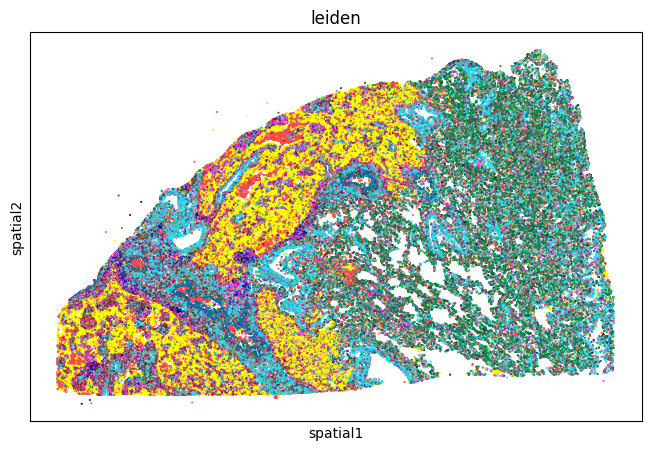

In [136]:
sq.pl.spatial_scatter(
    adata_5k_clust,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    legend_loc=None,
    wspace=0.4,
)

In [125]:
adata_5k_like_clust = sdata_v1_5k_like.tables["table_from_transcripts_5k_like"].copy()
sc.pp.normalize_total(adata_5k_like_clust, inplace=True)
sc.pp.log1p(adata_5k_like_clust)
sc.pp.pca(adata_5k_like_clust)
sc.pp.neighbors(adata_5k_like_clust)
# sc.tl.umap(adata_5k_like_clust)
sc.tl.leiden(adata_5k_like_clust)

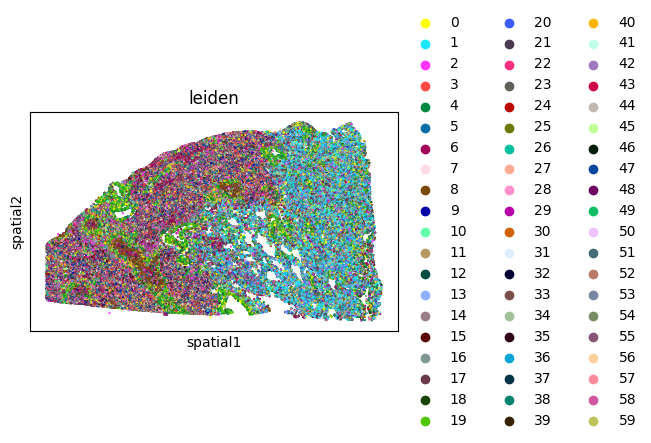

In [127]:
sq.pl.spatial_scatter(
    adata_5k_like_clust,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    wspace=0.4,
)

In [132]:
print("adata_5k_clust leiden groups:", adata_5k_clust.obs["leiden"].nunique() if "leiden" in adata_5k_clust.obs else "missing")
print("adata_5k_like_clust leiden groups:", adata_5k_like_clust.obs["leiden"].nunique() if "leiden" in adata_5k_like_clust.obs else "missing")

adata_5k_clust leiden groups: 149
adata_5k_like_clust leiden groups: 60


In [142]:
adata_5k_clust 

AnnData object with n_obs × n_vars = 267436 × 196
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_25_genes', 'pct_counts_in_top_150_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'leiden', 'leiden_colors'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [143]:
from sklearn.metrics import adjusted_rand_score

# Suppose you stored leiden labels in these columns:
# adata_v1.obs["leiden"] and adata_v1_5k_like.obs["leiden"]
# Make sure they are aligned by cell id / index.

# If both adatas have the same obs_names in the same order:
ari = adjusted_rand_score(
    adata_5k_clust.obs["leiden"].astype(str),
    adata_5k_like_clust.obs["leiden"].astype(str),
)
print("ARI:", ari)

ValueError: Found input variables with inconsistent numbers of samples: [267436, 217899]